In [51]:
import pandas as pd
import numpy as np
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score, precision_score

import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve
)

In [19]:
project_path = Path("/Users/irinafendley/Projects/Loan_Default")

data_path = project_path / "data/processed/loan_clean.csv"

df = pd.read_csv(data_path)

In [20]:
df = df.drop("LoanID", axis=1)

X = df.drop("Default", axis=1)
y = df["Default"]

In [21]:
X = pd.get_dummies(X, drop_first=True)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

model.fit(X_train, y_train)

/Users/irinafendley/Projects/Loan_Default/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [30]:
y_proba = model.predict_proba(X_test)[:, 1]

In [59]:
pd.DataFrame({
    "Actual_Default": y_test,
    "Probability_of_Default": y_proba
}).head(10)

,Actual_Default,Probability_of_Default
211648,0,0.233543
201101,0,0.172031
140423,0,0.309312
204530,0,0.628659
166481,0,0.317841
239445,0,0.057209
127976,0,0.773510
124925,0,0.365509
26516,1,0.775507
82635,0,0.532891


In [60]:
best_threshold = 0.3
y_pred_final = (y_proba > best_threshold).astype(int)

In [61]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nROC-AUC:")
print(roc_auc_score(y_test, y_proba))

Accuracy: 0.7797532798120227

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.81      0.87     45139
           1       0.27      0.52      0.36      5931

    accuracy                           0.78     51070
   macro avg       0.60      0.67      0.61     51070
weighted avg       0.85      0.78      0.81     51070


Confusion Matrix:
[[36725  8414]
 [ 2834  3097]]

ROC-AUC:
0.7466756099106733


In [28]:
for t in [0.3, 0.4, 0.5, 0.6]:
    y_pred = (y_proba > t).astype(int)
    print("Threshold:", t)
    print(classification_report(y_test, y_pred))

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.97      0.34      0.51     45139
           1       0.15      0.91      0.26      5931

    accuracy                           0.41     51070
   macro avg       0.56      0.63      0.38     51070
weighted avg       0.87      0.41      0.48     51070

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.96      0.52      0.67     45139
           1       0.18      0.82      0.30      5931

    accuracy                           0.55     51070
   macro avg       0.57      0.67      0.49     51070
weighted avg       0.87      0.55      0.63     51070

Threshold: 0.5
              precision    recall  f1-score   support

           0       0.94      0.68      0.79     45139
           1       0.22      0.69      0.33      5931

    accuracy                           0.68     51070
   macro avg       0.58      0.68      0.56     51070
weighted avg       0.86      

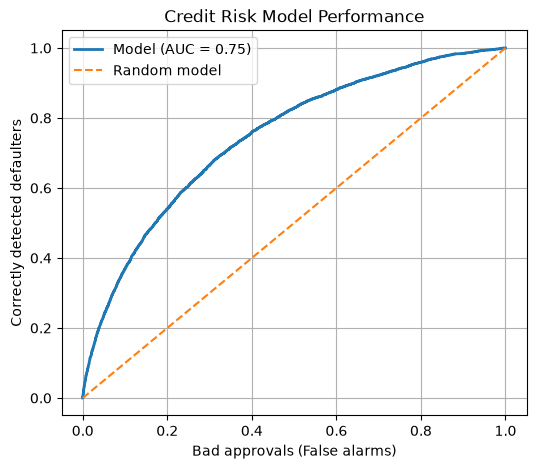

In [46]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))

plt.plot(fpr, tpr, label=f"Model (AUC = {roc_auc:.2f})", linewidth=2)
plt.plot([0, 1], [0, 1], "--", label="Random model")

plt.title("Credit Risk Model Performance")
plt.xlabel("Bad approvals (False alarms)")
plt.ylabel("Correctly detected defaulters")

plt.legend()
plt.grid()
plt.show()

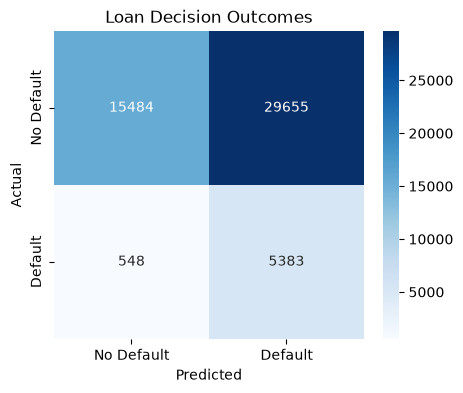

In [52]:
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Loan Decision Outcomes")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0.5, 1.5], ["No Default", "Default"])
plt.yticks([0.5, 1.5], ["No Default", "Default"])

plt.show()

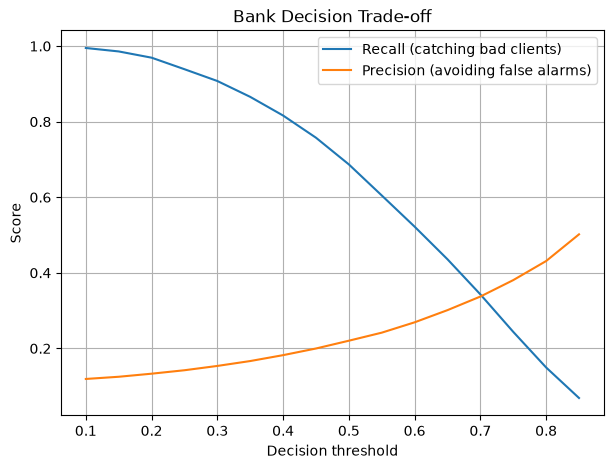

In [49]:
thresholds = np.arange(0.1, 0.9, 0.05)

recall_list = []
precision_list = []

for t in thresholds:
    y_pred_t = (y_proba > t).astype(int)
    recall_list.append(recall_score(y_test, y_pred_t))
    precision_list.append(precision_score(y_test, y_pred_t))

plt.figure(figsize=(7, 5))

plt.plot(thresholds, recall_list, label="Recall (catching bad clients)")
plt.plot(thresholds, precision_list, label="Precision (avoiding false alarms)")

plt.title("Bank Decision Trade-off")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.legend()
plt.grid()
plt.show()

In [53]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Impact on Risk": model.coef_[0]
})

feature_importance["Absolute Impact"] = feature_importance["Impact on Risk"].abs()

feature_importance = feature_importance.sort_values(
    "Absolute Impact",
    ascending=False
)

feature_importance.head(15)

,Feature,Impact on Risk,Absolute Impact
17,EmploymentType_Unemployed,0.297638,0.297638
11,HasCoSigner,-0.236411,0.236411
10,HasDependents,-0.229272,0.229272
12,Education_High School,0.197763,0.197763
5,NumCreditLines,0.174595,0.174595
8,DTIRatio,0.173387,0.173387
20,LoanPurpose_Business,0.129112,0.129112
18,MaritalStatus_Married,-0.125562,0.125562
9,HasMortgage,-0.121959,0.121959
22,LoanPurpose_Home,-0.115235,0.115235


In [63]:
import joblib

model_path = project_path / "data/models/logistic_regression.pkl"

joblib.dump(model, model_path)

['/Users/irinafendley/Projects/Loan_Default/data/models/logistic_regression.pkl']